In [87]:
# import polars as pl

# liang_enriched_samples = set(
#     pl.read_csv('liang_enriched_samples.tsv', separator='\t')
#         .with_columns([
#             pl.col('sample_id').str.replace(r'^D', '')
#         ])
#         ['sample_id']
# )

# liang_enriched_paired_samples = set(
#     pl.read_csv('liang_sample_file.tsv', separator='\t', ignore_errors=True)
#         .with_columns([
#             pl.col('Sample_id').cast(pl.String)
#         ])
#         .filter(
#             (pl.col('Sample_id').is_in(liang_enriched_samples)) &
#             (pl.col('Note').str.contains('infant stool')) &
#             (~pl.col('Note').str.starts_with('RNA '))
#         )
#         .group_by('Sample_id')
#         .len()
#         .filter(pl.col('len') == 2)
#         ['Sample_id']
# )

# (
#     pl.read_csv('liang_sample_file.tsv', separator='\t', ignore_errors=True)
#         .with_columns([
#             pl.col('Sample_id').cast(pl.String)
#         ])
#         .filter(
#             (pl.col('Sample_id').is_in(liang_enriched_paired_samples)) &
#             (~pl.col('Note').str.starts_with('RNA ')) &
#             (pl.col('Library_type').is_in(['Virome sequencing', 'Total microbial shotgun  sequencing']))
#         )
#         .with_columns([
#             pl.when(pl.col('Library_type') == 'Virome sequencing').then(pl.lit('enriched')).otherwise(pl.lit('unenriched')).alias('sample_type')
#         ])
#         .with_columns([
#             ('liang_' + pl.col('Sample_id') + '_' + pl.col('sample_type')).alias('sample'),
#             pl.col('Bioproject_accession').alias('bioproject'),
#             ('liang_' + pl.col('Sample_id')).alias('group'),
#             pl.col('Biosample_accession').alias('biosample'),
#             pl.col('Accession').alias('acc'),
#             pl.lit(None).alias('fastq_1'),
#             pl.lit(None).alias('fastq_2')
#         ])
#         [['sample', 'bioproject', 'group', 'biosample', 'acc', 'fastq_1', 'fastq_2']]
#         .write_csv('liang_enriched_paired_samplesheet.csv', separator=',')
# )

In [88]:
%%bash
# copy viralverify database
# mkdir -p /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/enriched_virome_test/results/uhvdb/databases
# cp -r /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/results/uhvdb/databases/viralverify /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/enriched_virome_test/results/uhvdb/databases/

In [89]:
%%bash
# run uhvdb/assemble, mine, and analyze
# sbatch figure_s1.sh

In [90]:
# load coverm results to identify viruses detected in bulk and enriched

import polars as pl
import math
import glob

df_lst = []

for file in glob.glob('results/uhvdb/analyze/prj*/*/*/coverm/contig/*.coverm.tsv'):
    sample_id = file.split('/')[-1].split('.')[0]
    group = sample_id.rsplit('_', 1)[0]
    df = (
        pl.read_csv(file, separator='\t', new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'])
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.lit(group).alias('group')
            ])
            .with_columns([
                (pl.col('covered_bases')/pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
            .filter(pl.col('breadth_ratio') >= 0.0)
    )
    df_lst.append(df)

coverm_df = pl.concat(df_lst)

In [91]:
enriched_viruses = set(
    coverm_df
        .filter(
            (pl.col('sample_id').str.contains('_enriched'))
            & (pl.col('breadth_ratio') >= 0.6)
        )
        .with_columns([
            (pl.col('group') + pl.col('contig_id')).alias('group_contig')
        ])
        ['group_contig']
)

In [92]:
(
    coverm_df
        .with_columns([
            (pl.col('group') + pl.col('contig_id')).alias('group_contig')
        ])
        .filter(
            (pl.col('group_contig').is_in(enriched_viruses)) &
            pl.col('sample_id').str.contains('_enriched')
        )
        .group_by('group')
        .len()
        .mean()
)

group,len
str,f64
null,55.846154


In [93]:
(
    coverm_df
        .with_columns([
            (pl.col('group') + pl.col('contig_id')).alias('group_contig')
        ])
        .filter(
            (pl.col('group_contig').is_in(enriched_viruses)) &
            pl.col('sample_id').str.contains('_unenriched')
        )
        .group_by('group')
        .len()
        .mean()
)

group,len
str,f64
null,23.589744


In [94]:
%%bash
# makeblastdb from enriched contigs
# blast dtrs in unenriched against enriched blastdb
# run anicalc

# # combine enriched virome viral contigs
# zcat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/enriched_virome_test/results/uhvdb/mine/prjna524703/*/*_enriched/uhvdb/virusfilter/*.fna.gz \
#     > combined_enriched_virus.fna

# zcat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/enriched_virome_test/results/uhvdb/mine/prjna524703/*/*_unenriched/uhvdb/virusfilter/*.fna.gz \
#     > combined_unenriched_virus.fna

# # create UHVDB HQ vOTU reps database
# mkdir -p enriched_blast
# micromamba run -n blast makeblastdb \
#         -in uhvdb_r2025_10.votu_reps.fna \
#         -dbtype nucl \
#         -out enriched_blast/uhvdb_r2025_10.votu_reps.blastdb

# # align sequences to UHVDB HQ vOTU reps
# micromamba run -n blast \
#     blastn \
#     -query combined_unenriched_virus.fna \
#     -db enriched_blast/uhvdb_r2025_10.votu_reps.blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 10000 \
#     -out unenriched_v_r2025_10_blast.tsv \
#     -num_threads 32

# micromamba run -n blast python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/anicalc.py \
#     -i unenriched_v_r2025_10_blast.tsv \
#     -o unenriched_v_r2025_10_anicalc.tsv

In [95]:
# load unenriched vs uhvdb blast results
unenriched_v_uhvdb = (
    pl.read_csv('unenriched_v_r2025_10_anicalc.tsv', separator='\t')
        .with_columns([
            ((pl.col('pid') * pl.col('tcov')) / 10000).alias('tani'),
            ((pl.col('pid') * pl.col('qcov')) / 10000).alias('qani'),
            pl.col('qname').str.split('_k').list[0].alias('sample_id')
        ])
        .sort('qani', descending=True)
        # .filter((pl.col('tani') >= 0.6) | (pl.col('qani') >= 0.6))
        .unique('qname')
)
unenriched_v_uhvdb.height

1000

In [96]:
uhvdb_info = (
    pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_cf_supplement/r2025_10_uhvdb_vclust_votu_cluster_info_final.tsv', separator='\t')
    .filter(pl.col('contig_id') == pl.col('votu_rep'))
    .unique(pl.col('contig_id'))
)

In [97]:
# load bacphlip results for UHVDB
bacphlip_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/uhvdb_*_chunks/*.fna.bacphlip'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], new_columns=['contig_id', 'virulent', 'temperate'])
    )
    bacphlip_lst.append(df)

bacphlip_df = (
    pl.concat(bacphlip_lst)
        .with_columns([
            pl.when(pl.col('contig_id').str.contains('provirus')).then(pl.lit(0.0)).otherwise(pl.col('virulent')).alias('virulent')
        ])
)

In [340]:
# load instrain gene results
instrain_lst = []
instrain_gene_lst = []
genes_of_interest_lst = []

for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s19a/enriched_virome_test/results/uhvdb/analyze/prjna524703/liang_*/liang_*_unenriched/coverm/contig/pharokka/pharokka_cds_final_merged_output.tsv'):
    genes_of_interest_lst.append(
        pl.read_csv(file, separator='\t', null_values=['None'], columns=['gene', 'contig', 'annot', 'category'])
            .with_columns([
                pl.col('gene').str.split('_CDS',).list[0] + pl.col('gene').str.split('_CDS',).list[1].str.replace(r'0+', '')
            ])
            [['gene', 'category', 'annot']]
    )

genes_of_interest_df = pl.concat(genes_of_interest_lst).unique()

for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s19a/enriched_virome_test/results/uhvdb/analyze/prjna524703/liang_*/liang_*_unenriched/instrain/output/instrain_gene_info.tsv'):
    df = (
        pl.read_csv(file, separator='\t', columns=['scaffold', 'gene', 'coverage', 'breadth', 'partial', 'pNpS_variants'])
            .join(genes_of_interest_df, on='gene', how='inner')
            .rename({'coverage': 'gene_coverage', 'breadth': 'gene_breadth'})
            .with_columns([pl.col('pNpS_variants').cast(pl.Float64)])
    )
    instrain_gene_lst.append(df)

instrain_gene_df = (
    pl.concat(instrain_gene_lst)
)

instrain_samples = []
instrain_groups = []

for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s19a/enriched_virome_test/results/uhvdb/analyze/prjna524703/liang_*/liang_*_unenriched/instrain/output/instrain_scaffold_info.tsv'):
    sample = file.split('/')[-4]
    group = file.split('/')[-5]
    instrain_samples.append(sample)
    instrain_groups.append(group)

    df = (
        pl.read_csv(file, separator='\t', columns=['scaffold', 'coverage', 'breadth'])
            .rename({'coverage': 'scaffold_coverage', 'breadth': 'scaffold_breadth'})
            .join(instrain_gene_df, on='scaffold', how='inner')
            .rename({'scaffold': 'contig_id'})
            .with_columns([
                pl.lit(sample).alias('sample_id')
            ])
    )
    instrain_lst.append(df)

instrain_df = (
    pl.concat(instrain_lst)
)

In [341]:
unenriched_v_enriched = (
    coverm_df
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df.filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        .join(uhvdb_info, on='contig_id', how='left')
        .join(instrain_df, on=['contig_id', 'sample_id'], how='left')
        .filter(pl.col('group').is_in(instrain_groups))
        .join(bacphlip_df, on='contig_id', how='left')
        .with_columns([
            pl.col('mean_enriched').fill_null(0.0).alias('mean_enriched'),
        ])
        .fill_null(0.01)
        .with_columns([
            pl.when((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01)).then(pl.lit('Both'))
                .when((pl.col('breadth_ratio_enriched') <= 0.01 )  & (pl.col('breadth_ratio') > 0.01)).then(pl.lit('U only'))
                .alias('detection_status'),
            pl.when(pl.col('group').is_not_null()).then(pl.col('group')).otherwise(pl.col('group_enriched')).alias('group')
        ])
)

(
    unenriched_v_enriched
        .unique(['contig_id', 'group'])
        .group_by(['detection_status'])
        .len()
)

detection_status,len
str,u32
"""U only""",2128
"""Both""",678


In [342]:
for i in [ 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8 ]:
    low_breadth_contigs = (
        unenriched_v_enriched
            .unique(['contig_id', 'group'])
            .filter((pl.col('breadth_ratio') < i))
    )

    values = (
        low_breadth_contigs
            .group_by('detection_status')
            .len()
            .sort('detection_status')
    )

    print(
        (values.filter(pl.col('detection_status') == 'U only'))[0,1] / values['len'].sum(), values['len'].sum()
    )

low_breadth_contigs = (
    unenriched_v_enriched
        .unique(['contig_id', 'group'])
        .filter((pl.col('breadth_ratio') < 0.6))
)

low_breadth_contigs_set = set(low_breadth_contigs['contig_id'])

print(
    unenriched_v_enriched
        .unique(['contig_id', 'group'])
        .filter(~pl.col('contig_id').is_in(low_breadth_contigs_set))
        .group_by('detection_status')
        .len()
        .sort('detection_status')
)

1.0 23
0.9636363636363636 55
0.9650655021834061 229
0.9530516431924883 426
0.938622754491018 668
0.9083333333333333 1080
0.8849294729027468 1347
0.8591715976331361 1690
shape: (2, 2)
┌──────────────────┬──────┐
│ detection_status ┆ len  │
│ ---              ┆ ---  │
│ str              ┆ u32  │
╞══════════════════╪══════╡
│ Both             ┆ 597  │
│ U only           ┆ 1290 │
└──────────────────┴──────┘


In [357]:
unenriched_v_enriched.group_by('annot').len().sort('len', descending=True).head(10)

annot,len
str,u32
"""hypothetical protein""",221407
"""integrase""",6698
"""terminase large subunit""",5400
"""tail protein""",5177
"""portal protein""",5072
"""transcriptional regulator""",5026
"""DNA methyltransferase""",4809
"""endolysin""",4471
"""major head protein""",4430


In [351]:
for i in [ 0, 0.25, 0.5, 0.75, 0.8, 0.9 ]:
    no_struct_contigs = (
        unenriched_v_enriched
            .filter(~pl.col('contig_id').is_in(low_breadth_contigs_set))
            .group_by(['contig_id', 'group', 'detection_status'])
            .agg([
                (
                    (
                        (pl.col('category') == 'moron, auxiliary metabolic gene and host takeover')
                    ) & 
                    (pl.col('gene_breadth') > i)
                ).sum().alias('structural_count')
            ])
            .filter(pl.col('structural_count') >= 7)
    )


    values = (
        no_struct_contigs
            .group_by('detection_status')
            .len()
            .sort('detection_status')
    )

    print(
        (values.filter(pl.col('detection_status') == 'U only'))[0,1] / values['len'].sum(), values['len'].sum()
    )

# print(
#     unenriched_v_enriched
#         .unique(['contig_id', 'group'])
#         # .filter(~pl.col('contig_id').is_in(low_breadth_contigs_set))
#         .filter(pl.col('contig_id').is_in(no_struct_contigs_set))
#         .group_by('detection_status')
#         .len()
#         .sort('detection_status')
# )

0.84 100
0.851063829787234 94
0.9047619047619048 84
0.8933333333333333 75
0.8933333333333333 75
0.8955223880597015 67


In [370]:
for i in [ 0, 0.25, 0.5, 0.75, 0.8, 0.9, 1.0 ]:
    no_struct_contigs = (
        unenriched_v_enriched
            .filter(~pl.col('contig_id').is_in(low_breadth_contigs_set))
            .group_by(['contig_id', 'group', 'detection_status'])
            .agg([
                (
                    (
                        (pl.col('category') == 'integration and excision')
                    ) & 
                    (pl.col('gene_breadth') <= i)
                ).sum().alias('structural_count')
            ])
            .filter(pl.col('structural_count') >= 1)
    )


    values = (
        no_struct_contigs
            .group_by('detection_status')
            .len()
            .sort('detection_status')
    )

    print(
        (values.filter(pl.col('detection_status') == 'U only'))[0,1] / values['len'].sum(), values['len'].sum()
    )

# print(
#     unenriched_v_enriched
#         .unique(['contig_id', 'group'])
#         # .filter(~pl.col('contig_id').is_in(low_breadth_contigs_set))
#         .filter(pl.col('contig_id').is_in(no_struct_contigs_set))
#         .group_by('detection_status')
#         .len()
#         .sort('detection_status')
# )

shape: (0,)
Series: 'len' [f64]
[
] 0
0.7651515151515151 396
0.7340267459138187 673
0.7515991471215352 938
0.742 1000
0.725177304964539 1128
0.7001321003963011 1514


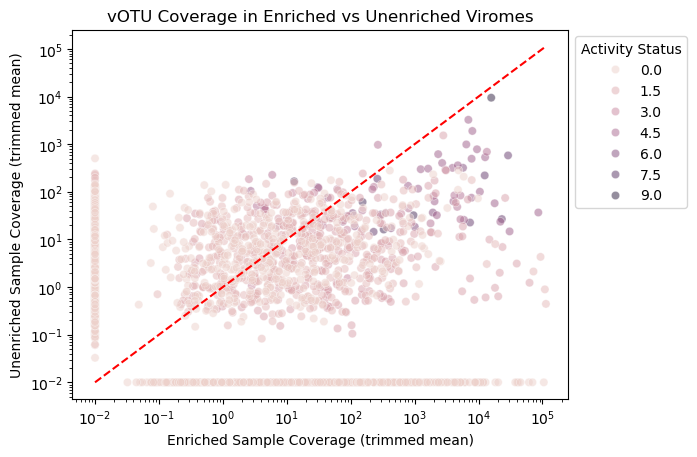

In [374]:
# load checkv results for unenriched 
checkv_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s19a/enriched_virome_test/results/uhvdb/mine/prjna524703/*/*/checkv/*_unenriched_quality_summary.tsv.gz'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'])
            [['contig_id', 'provirus', 'completeness', 'host_genes', 'viral_genes', 'completeness_method']]
    )
    checkv_lst.append(df)

checkv_df = (
    pl.concat(checkv_lst)
)

# load propagate results for unenriched
propagate_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s19a/enriched_virome_test/results/uhvdb/analyze/prjna524703/liang_*/liang_*_unenriched/propagate/*_unenriched.propagate.tsv'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], columns=['prophage', 'prophage_len', 'host', 'CohenD', 'prophage-host_ratio'])
            .with_columns([
                pl.col('prophage').cast(pl.String),
                pl.col('host').cast(pl.String),
                pl.col('prophage_len').cast(pl.Int64),
                pl.col('CohenD').cast(pl.Float64),
                pl.col('prophage-host_ratio').cast(pl.Float64),
                pl.col('prophage').str.split('_k').list[0].alias('sample_id')
            ])
    )
    propagate_lst.append(df)

propagate_df = (
    pl.concat(propagate_lst)
)


# # identify mvirs active viruses in unenriched
# !cat results/uhvdb/analyze/prjna524703/liang_*/liang_*_unenriched/strobealign/liang_*_unenriched.mvirs.fasta | \
#     grep "^>" > unenriched_mvirs_contig_ids.txt

mvirs_contigs = (
    pl.read_csv('unenriched_mvirs_contig_ids.txt', separator=' ', has_header=False, new_columns=['mvirs_id'])
        .with_columns([
            pl.col('mvirs_id').str.replace('>', '').str.split(':').list[0].alias('contig_id_no_prophage'),
            pl.col('mvirs_id').str.split('OPRs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_oprs'),
            pl.col('mvirs_id').str.split('HSs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_clipped'),
        ])
        .with_columns([
            pl.col('contig_id_no_prophage').str.split('_k').list[0].alias('sample_id')
        ])
)

uhvdb_info = (
    pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_cf_supplement/r2025_10_uhvdb_vclust_votu_cluster_info_final.tsv', separator='\t')
    .filter(pl.col('contig_id') == pl.col('votu_rep'))
    .unique(pl.col('contig_id'))
)

# combine all data together
enrich_v_unenrich = (
    coverm_df
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(uhvdb_info, on='contig_id', how='left')
        .join(bacphlip_df, on='contig_id', how='left')
        .join(unenriched_v_uhvdb, left_on=['contig_id', 'sample_id'], right_on=['tname', 'sample_id'], how='left')
        .with_columns([
            pl.col('qname').str.split('|provirus').list[0].alias('contig_id_no_prophage')
        ])
        .join(propagate_df, left_on=['qname', 'sample_id'], right_on=['prophage', 'sample_id'], how='left')
        .join(checkv_df, left_on='qname', right_on='contig_id', how='left')
        .join(mvirs_contigs, on=['contig_id_no_prophage', 'sample_id'], how='left')
        .with_columns([
            # breadth of coverage as an indicator that a virus is not fragmented
            pl.when((pl.col('breadth') >= 0.90) | (pl.col('breadth_ratio') >= 0.9)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('breadth_score'),
            # reference evidence of activity
            pl.when(pl.col('completeness_method').str.contains('DTR')).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_dtr_score'),
            pl.when((pl.col('virulent') >= 0.95)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_virulent_score'),
            # complete genome activity evidence
            pl.when((pl.col('completeness_method_right').str.contains('TR'))).then(pl.lit(3.0))
                .otherwise(pl.lit(0.0)).alias('dtr_score'),
            pl.when((pl.col('num_oprs') + pl.col('num_clipped')) >= 5).then(pl.lit(3.0))
                .otherwise(pl.lit(0.0)).alias('mvirs_score'),
            # fragment evidence of activity
            pl.when((pl.col('CohenD') >= 1.5)).then(pl.lit(3.0))
                .when((pl.col('CohenD') >= 0.7)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('propagate_score'),
        ])
        .group_by(['contig_id', 'sample_id'])
        .agg([
            pl.col('breadth_score').max().alias('breadth_score'),
            pl.col('ref_dtr_score').max().alias('ref_dtr_score'),
            pl.col('ref_virulent_score').max().alias('ref_virulent_score'),
            pl.col('group').first().alias('group'),
            pl.col('qname').first().alias('qname'),
            pl.col('trimmed_mean').first().alias('trimmed_mean'),
            pl.col('mean').first().alias('mean'),
            pl.col('breadth').first().alias('breadth'),
            pl.col('breadth_ratio').first().alias('breadth_ratio'),
            pl.col('completeness_method').first().alias('completeness_method'),
            pl.col('completeness').first().alias('completeness'),
            pl.col('virulent').first().alias('virulent'),
            pl.col('dtr_score').max().alias('dtr_score'),
            pl.col('num_oprs').max().alias('num_oprs'),
            pl.col('num_clipped').max().alias('num_clipped'),
            pl.col('CohenD').max().alias('CohenD'),
            pl.col('prophage-host_ratio').max().alias('prophage-host_ratio'),
            pl.col('mvirs_score').max().alias('mvirs_score'),
            pl.col('propagate_score').max().alias('propagate_score'),
        ])
        .with_columns([
            (
                pl.col('breadth_score') +
                pl.col('ref_dtr_score') +
                pl.col('ref_virulent_score')
                + pl.col('dtr_score') +
                pl.col('mvirs_score') +
                pl.col('propagate_score')
            ).alias('activity_score')
        ])
        .with_columns([
            (
                pl.col('breadth_score') +
                pl.col('ref_dtr_score') +
                pl.col('ref_virulent_score')
            ).alias('reference_activity_score')
        ])
        .sort('activity_score', descending=True)
        .join(
            coverm_df.filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        .fill_null(0.01)
        .with_columns([
            pl.when((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6)).then(pl.lit('Both Detected'))
                .when((pl.col('breadth_ratio_enriched') <= 0.01)  & (pl.col('breadth_ratio') >= 0.6)).then(pl.lit('Unenriched Only'))
                .when((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') <= 0.01)).then(pl.lit('Enriched Only'))
                .otherwise(pl.lit('Not Detected')).alias('detection_status'),
            pl.when(pl.col('group').is_not_null()).then(pl.col('group')).otherwise(pl.col('group_enriched')).alias('group')
        ])
)

# plot results
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=enrich_v_unenrich,
    x='trimmed_mean_enriched',
    y='trimmed_mean',
    alpha=0.5,
    hue='activity_score'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Enriched Sample Coverage (trimmed mean)')
plt.ylabel('Unenriched Sample Coverage (trimmed mean)')
plt.title('vOTU Coverage in Enriched vs Unenriched Viromes')
#hide legend
plt.legend(title='Activity Status', loc='upper left', bbox_to_anchor=(1, 1))
# plot line on diagonal
max_cov = max(enrich_v_unenrich['trimmed_mean_enriched'].max(), enrich_v_unenrich['trimmed_mean'].max())
plt.plot([0.01, max_cov], [0.01, max_cov], color='red', linestyle='--')
# plt.plot([10, 10], [0, max_cov], color='grey', linestyle='--')
plt.show()

In [175]:
(
    enrich_v_unenrich
        .with_columns([
            (pl.col('breadth_score') > 0.01).sum().alias('num_breadth_score'),
            (pl.col('ref_dtr_score') > 0.01).sum().alias('num_ref_dtr_score'),
            (pl.col('ref_virulent_score') > 0.01).sum().alias('num_ref_virulent_score'),
            (pl.col('dtr_score') > 0.01).sum().alias('num_dtr_score'),
            (pl.col('mvirs_score') > 0.01).sum().alias('num_mvirs_score'),
            (pl.col('propagate_score') > 0.01).sum().alias('num_propagate_score')
        ])
        [['num_breadth_score', 'num_ref_dtr_score', 'num_ref_virulent_score', 'num_dtr_score', 'num_mvirs_score', 'num_propagate_score']]
        .head(1)
)

num_breadth_score,num_ref_dtr_score,num_ref_virulent_score,num_dtr_score,num_mvirs_score,num_propagate_score
u32,u32,u32,u32,u32,u32
831,736,105,46,29,51


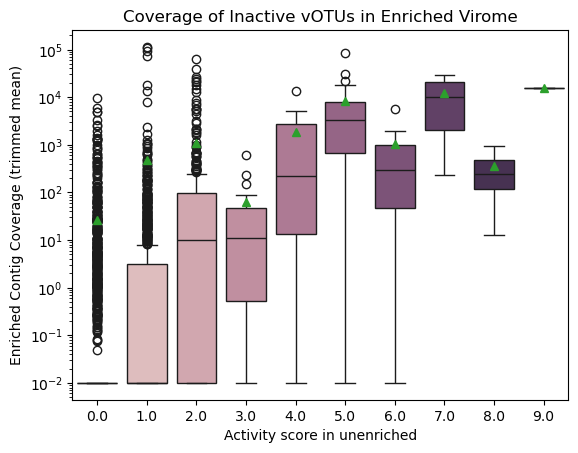

In [108]:
sns.boxplot(
    data=enrich_v_unenrich.filter((pl.col('trimmed_mean') > 0.01)),
    x='activity_score',
    y='trimmed_mean_enriched',
    hue='activity_score',
    showmeans=True
)
plt.yscale('log')
plt.xlabel('Activity score in unenriched')
plt.ylabel('Enriched Contig Coverage (trimmed mean)')
plt.title('Coverage of Inactive vOTUs in Enriched Virome')
# hide legend
plt.legend().remove()
plt.show()

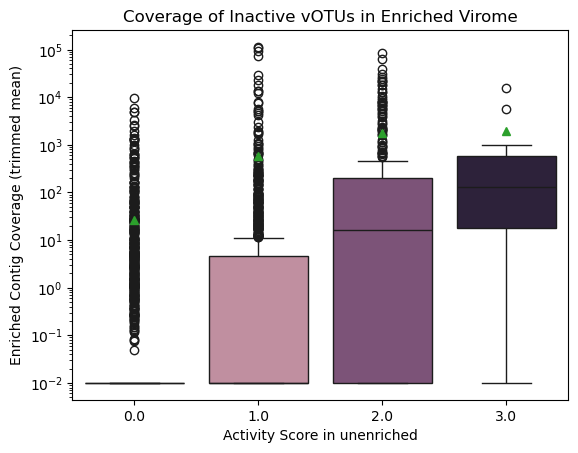

In [109]:
sns.boxplot(
    data=enrich_v_unenrich.filter((pl.col('trimmed_mean') > 0.01)),
    x='reference_activity_score',
    y='trimmed_mean_enriched',
    hue='reference_activity_score',
    showmeans=True
)
plt.yscale('log')
plt.xlabel('Activity Score in unenriched')
plt.ylabel('Enriched Contig Coverage (trimmed mean)')
plt.title('Coverage of Inactive vOTUs in Enriched Virome')
# hide legend
plt.legend().remove()
plt.show()

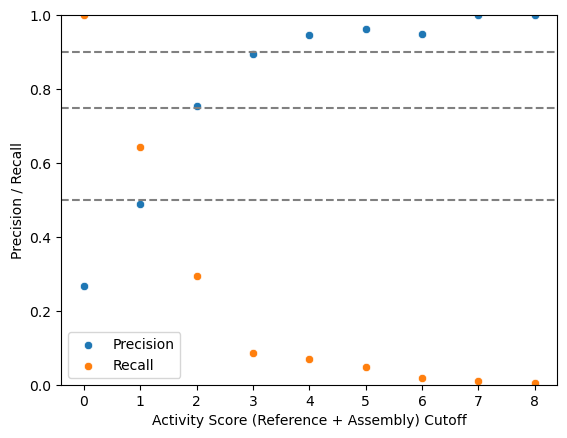

In [110]:
precision_values = []
recall_values = []
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    if (enrich_v_unenrich
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.axhline(y=0.75, color='grey', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')

# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Activity Score (Reference + Assembly) Cutoff')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

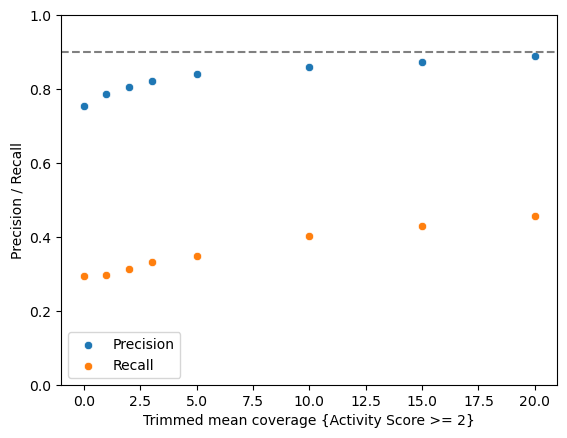

In [111]:
precision_values = []
recall_values = []
activity_score = 2

for i in [0, 1, 2, 3, 5, 10, 15, 20]:
    if (enrich_v_unenrich
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Trimmed mean coverage {Activity Score >= %d}' % activity_score)
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

1018


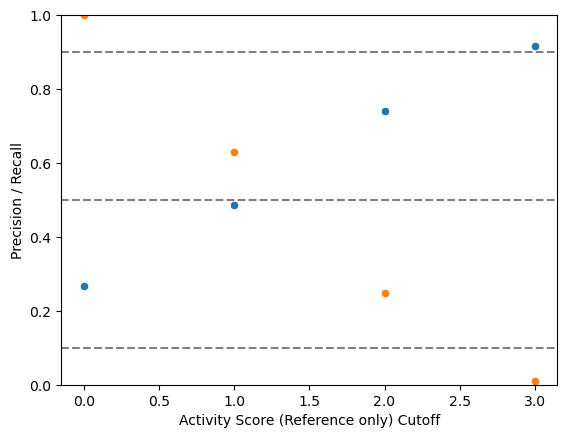

In [112]:
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0, 1, 2, 3, 4, 5]:
    if (enrich_v_unenrich
            .filter(pl.col('reference_activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('reference_activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('reference_activity_score') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('reference_activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Activity Score (Reference only) Cutoff')
plt.ylabel('Precision / Recall')
plt.show()

1018


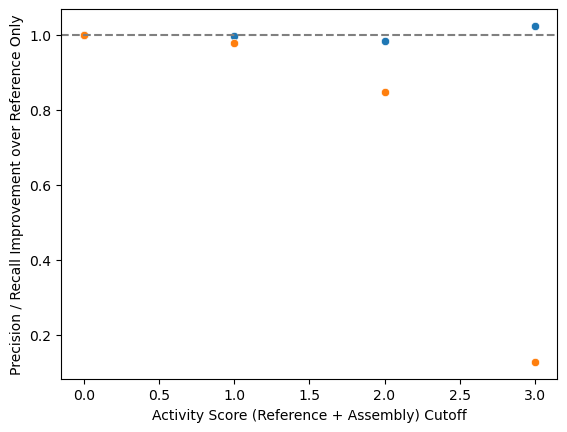

In [113]:
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0, 1, 2, 3]:
    if (enrich_v_unenrich
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        (
            enrich_v_unenrich
                .filter(pl.col('reference_activity_score') >= i)
                .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
                .height
            /
            enrich_v_unenrich
                .filter(pl.col('reference_activity_score') >= i)
                .filter((pl.col('breadth_ratio') > 0.01))
                .height
        ) /
        (
            enrich_v_unenrich
                .filter(pl.col('activity_score') >= i)
                .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
                .height
            /
            enrich_v_unenrich
                .filter(pl.col('activity_score') >= i)
                .filter((pl.col('breadth_ratio') > 0.01))
                .height
        )
    )

    recall_values.append(
        (
            enrich_v_unenrich
                .filter(pl.col('reference_activity_score') >= i)
                .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
                .height
            /
            enrich_v_unenrich
                .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
                .height
        ) /
        (
            enrich_v_unenrich
                .filter(pl.col('activity_score') >= i)
                .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
                .height
            /
            enrich_v_unenrich
                .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
                .height
        )
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3],
    y=recall_values
)
# add count 

plt.axhline(y=1.0, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
# plt.ylim(0, 1.5)
plt.xlabel('Activity Score (Reference + Assembly) Cutoff')
plt.ylabel('Precision / Recall Improvement over Reference Only')
plt.show()

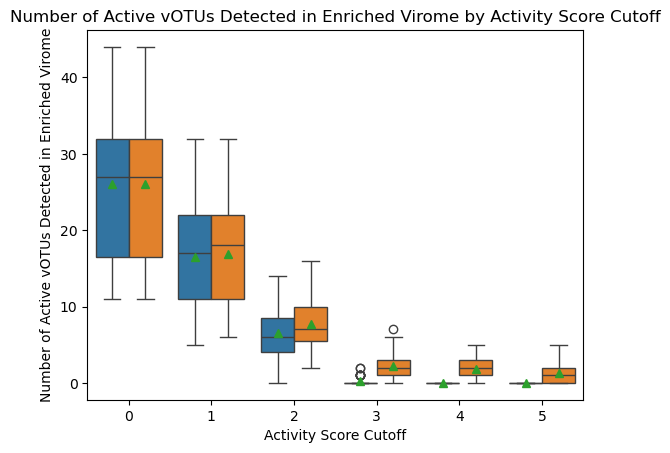

In [114]:
assembly_values = []
reference_values = []

for i in [0, 1, 2, 3, 4, 5]:
    if (enrich_v_unenrich
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    reference_values = (
        enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .group_by('group')
            .agg((pl.col('reference_activity_score') >= i).sum().alias('num_active_votus'))
            .with_columns([
                pl.lit('reference').alias('type'),
                pl.lit(i).alias('activity_score_cutoff')
            ])
            [['group', 'num_active_votus', 'type', 'activity_score_cutoff']]
    )
    assembly_values = (
        enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .group_by('group')
            .agg((pl.col('activity_score') >= i).sum().alias('num_active_votus'))
            .with_columns([
                pl.lit('assembly').alias('type'),
                pl.lit(i).alias('activity_score_cutoff')
            ])
            [['group', 'num_active_votus', 'type', 'activity_score_cutoff']]
    )

    sns.boxplot(
        data=pl.concat([reference_values, assembly_values]),
        x='activity_score_cutoff',
        y='num_active_votus',
        hue='type',
        showmeans=True
    )


# # scatterplot of precision vs breadth cutoff
# sns.boxplot(
#     x=[0, 1, 2, 3, 4, 5],
#     y=reference_values
# )
# sns.scatterplot(
#     x=[0, 1, 2, 3, 4, 5],
#     y=assembly_values
# )

# plt.axhline(y=1.0, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
# plt.ylim(0, 1.5)
# # hide legend
plt.xlabel('Activity Score Cutoff')
plt.ylabel('Number of Active vOTUs Detected in Enriched Virome')
plt.title('Number of Active vOTUs Detected in Enriched Virome by Activity Score Cutoff')
plt.legend().remove()
plt.show()

1018


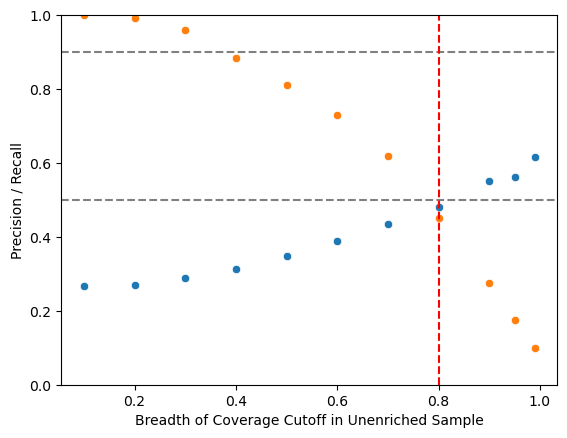

In [115]:
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') >0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') >0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') >0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.axvline(x=0.8, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth of Coverage Cutoff in Unenriched Sample')
plt.ylabel('Precision / Recall')
plt.show()

920


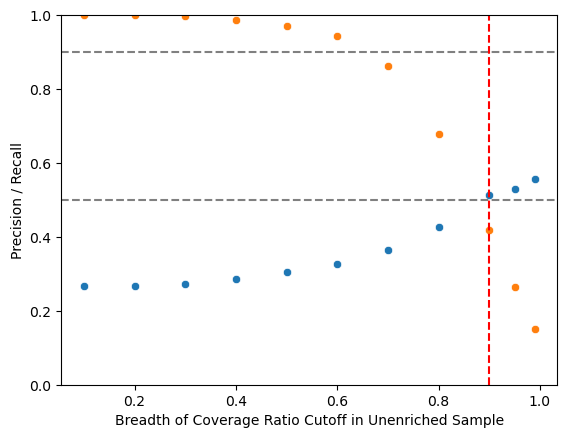

In [116]:
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') > 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('breadth_ratio_enriched') >0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.axvline(x=0.9, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth of Coverage Ratio Cutoff in Unenriched Sample')
plt.ylabel('Precision / Recall')
plt.show()

In [385]:
enrich_v_unenrich

contig_id,sample_id,breadth_score,ref_dtr_score,ref_virulent_score,group,qname,trimmed_mean,mean,breadth,breadth_ratio,completeness_method,completeness,virulent,dtr_score,num_oprs,num_clipped,CohenD,prophage-host_ratio,mvirs_score,propagate_score,activity_score,reference_activity_score,contig_id_enriched,trimmed_mean_enriched,mean_enriched,variance,covered_bases,length,sample_id_enriched,group_enriched,breadth_enriched,expected_breadth,breadth_ratio_enriched,detection_status
str,str,f64,f64,f64,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,str,f64,f64,f64,str
"""UHGV-0210062""","""liang_3451_unenriched""",1.0,1.0,1.0,"""liang_3451""","""liang_3451_unenriched_k251_146…",9452.807,9737.207,1.0,1.0,"""DTR""",100.0,1.0,3.0,1918.0,4.0,0.01,0.01,3.0,0.0,9.0,3.0,"""UHGV-0210062""",15793.529,16456.393,8.433957e7,58378.0,58378.0,"""liang_3451_enriched""","""liang_3451""",1.0,1.0,1.0,"""Both Detected"""
"""UHGV-0055008""","""liang_4001_unenriched""",1.0,1.0,0.0,"""liang_4001""","""liang_4001_unenriched_k251_515…",32.185524,32.181076,0.930935,0.930935,"""DTR""",100.0,0.025,0.0,13.0,6.0,1.86452,1.962537,3.0,3.0,8.0,2.0,"""UHGV-0055008""",961.60565,962.343,232101.13,58160.0,61782.0,"""liang_4001_enriched""","""liang_4001""",0.941375,1.0,0.941375,"""Both Detected"""
"""UHGV-0205684""","""liang_3964_unenriched""",1.0,1.0,0.0,"""liang_3964""","""liang_3964_unenriched_k251_271…",61.103035,61.152447,1.0,1.0,"""DTR""",100.0,0.025,3.0,37.0,10.0,0.01,0.01,3.0,0.0,8.0,2.0,"""UHGV-0205684""",153.52011,157.81406,5983.72,38668.0,38668.0,"""liang_3964_enriched""","""liang_3964""",1.0,1.0,1.0,"""Both Detected"""
"""UHGV-0208094""","""liang_3681_unenriched""",1.0,1.0,0.0,"""liang_3681""","""liang_3681_unenriched_k251_193…",16.15846,16.307037,1.0,1.000001,"""DTR""",100.0,0.0,3.0,11.0,3.0,0.01,0.01,3.0,0.0,8.0,2.0,"""UHGV-0208094""",328.1061,331.86996,14761.228,43679.0,43679.0,"""liang_3681_enriched""","""liang_3681""",1.0,1.0,1.0,"""Both Detected"""
"""UHGV-0213310""","""liang_370_unenriched""",1.0,1.0,0.0,"""liang_370""","""liang_370_unenriched_k251_1918…",165.95268,162.63258,0.930995,0.930995,"""DTR""",100.0,0.0,0.0,57.0,39.0,2.660882,2.15277,3.0,3.0,8.0,2.0,"""UHGV-0213310""",13.035398,14.310874,225.34912,38197.0,41707.0,"""liang_370_enriched""","""liang_370""",0.915841,0.999993,0.915848,"""Both Detected"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,null,0.01,0.01,0.01,"""liang_3944""",null,0.01,0.01,0.01,0.01,null,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,"""HMP_1092.k81_27405""",718.7538,738.99365,230614.5,27563.0,30490.0,"""liang_3944_enriched""","""liang_3944""",0.904001,1.0,0.904001,"""Enriched Only"""
null,null,0.01,0.01,0.01,"""liang_4001""",null,0.01,0.01,0.01,0.01,null,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,"""SAMN19855118.contig00011|provi…",0.130774,0.237304,0.3725226,7916.0,47507.0,"""liang_4001_enriched""","""liang_4001""",0.166628,0.179363,0.929,"""Enriched Only"""
null,null,0.01,0.01,0.01,"""liang_3944""",null,0.01,0.01,0.01,0.01,null,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,"""SAMEA10740010_k141_136413""",186.14139,209.4234,41575.125,36273.0,37588.0,"""liang_3944_enriched""","""liang_3944""",0.965015,1.0,0.965015,"""Enriched Only"""


88


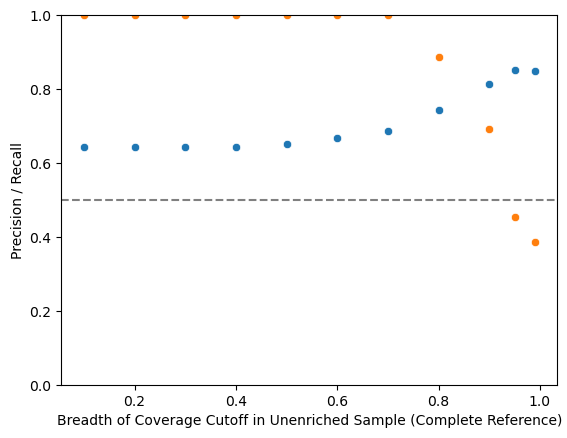

In [379]:
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('completeness') == 100)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter(pl.col('completeness') == 100)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('completeness') == 100)
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('completeness') == 100)
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('completeness') == 100)
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('completeness') == 100)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
# plt.axvline(x=0.1, color='red', linestyle='--')
# plt.axvline(x=0.95, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
# plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth of Coverage Cutoff in Unenriched Sample (Complete Reference)')
plt.ylabel('Precision / Recall')
plt.show()

399


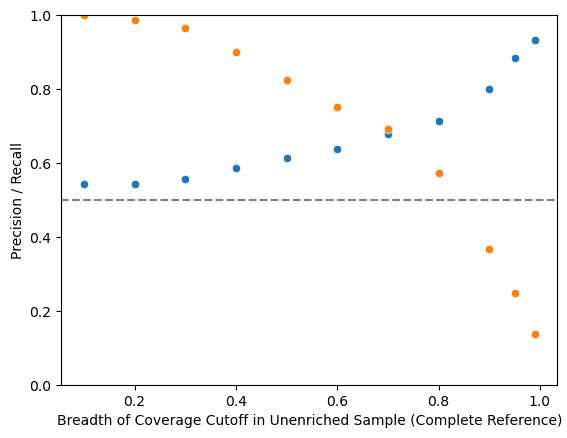

In [378]:
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('completeness_method').str.contains('DTR'))
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter(pl.col('completeness_method').str.contains('DTR'))
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('completeness_method').str.contains('DTR'))
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('completeness_method').str.contains('DTR'))
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('completeness_method').str.contains('DTR'))
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('completeness_method').str.contains('DTR'))
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
# plt.axvline(x=0.1, color='red', linestyle='--')
# plt.axvline(x=0.95, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
# plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth of Coverage Cutoff in Unenriched Sample (Complete Reference)')
plt.ylabel('Precision / Recall')
plt.show()

251


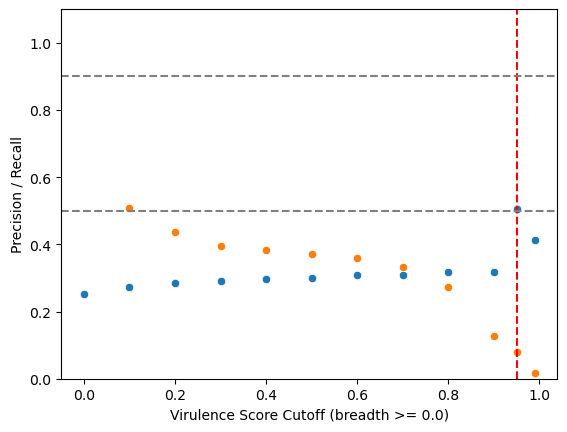

In [118]:
precision_values = []
recall_values = []
breadth = 0.0
print(enrich_v_unenrich
            .filter(pl.col('virulent') > 0.5)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') >= 0.6))
            .height
)
for i in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('breadth') >= breadth)
            .filter(pl.col('virulent') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') >= 0.6))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= breadth)
            .filter(pl.col('virulent') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('breadth') >= breadth)
            .filter(pl.col('virulent') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= breadth)
            .filter(pl.col('virulent') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('virulent') > 0.0)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') >= 0.6))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
# plt.axvline(x=0.0, color='red', linestyle='--')
plt.axvline(x=0.95, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Virulence Score Cutoff (breadth >= {})'.format(breadth))
plt.ylabel('Precision / Recall')
plt.show()

44


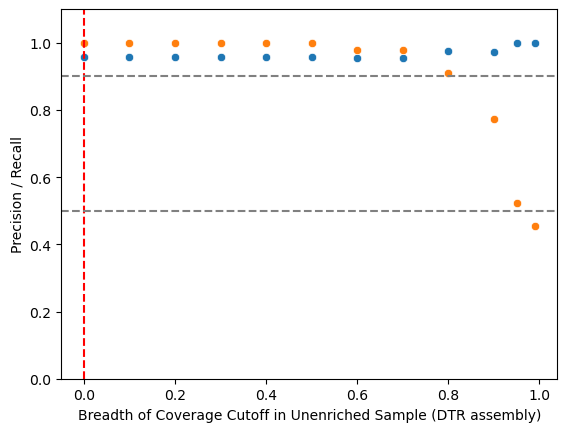

In [119]:
precision_values = []
recall_values = []
tani = 0.0

print(enrich_v_unenrich
            .filter(pl.col('dtr_score') > 0)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('dtr_score') > 0)
            # .filter(pl.col('tani') >= tani)
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('dtr_score') > 0)
            # .filter(pl.col('tani') >= tani)
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('dtr_score') > 0)
            # .filter(pl.col('tani') >= tani)
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('dtr_score') > 0)
            # .filter(pl.col('tani') >= tani)
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('dtr_score') > 0)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axvline(x=0.0, color='red', linestyle='--')
# plt.axvline(x=0.9, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Breadth of Coverage Cutoff in Unenriched Sample (DTR assembly)')
plt.ylabel('Precision / Recall')
plt.show()

25
25


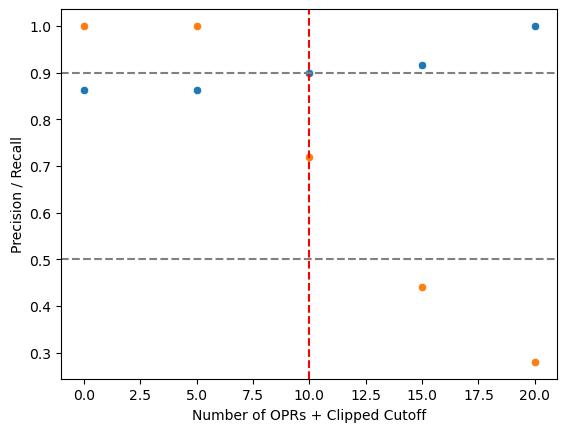

In [120]:
precision_values = []
recall_values = []
tani = 0.6
print(enrich_v_unenrich
            .filter(pl.col('num_oprs') > 0.01)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
)
print(enrich_v_unenrich
            .filter(pl.col('num_oprs') >  0.01)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('breadth_ratio_enriched') > 0.01))
            .height
)
for i in [0,5,10,15,20]:
    if (enrich_v_unenrich
            .filter(pl.col('num_oprs') > 0.01)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('num_oprs') + pl.col('num_clipped')) >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('num_oprs') > 0.01)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('num_oprs') + pl.col('num_clipped')) >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('num_oprs') > 0.01)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('num_oprs') + pl.col('num_clipped')) >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('num_oprs') > 0.01)
            # .filter(pl.col('tani') >= tani)
            .filter((pl.col('num_oprs') + pl.col('num_clipped')) >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('num_oprs') > 0.01)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0,5,10,15,20],
    y=precision_values
)
sns.scatterplot(
    x=[0,5,10,15,20],
    y=recall_values
)
plt.axvline(x=10, color='red', linestyle='--')
# plt.axvline(x=0.95, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.xlabel('Number of OPRs + Clipped Cutoff')
plt.ylabel('Precision / Recall')
# plt.ylim(0, 1.1)
plt.show()

41
51


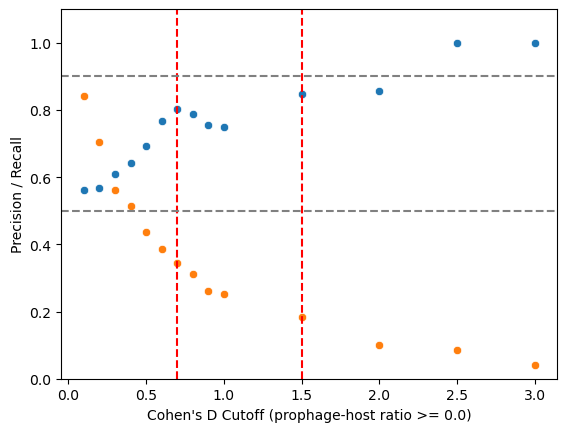

In [121]:
precision_values = []
recall_values = []
tani = 0.0
print(enrich_v_unenrich
            .filter(pl.col('CohenD') > 0.7)
            .filter(pl.col('prophage-host_ratio') >= tani)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
)
print(enrich_v_unenrich
            .filter(pl.col('CohenD') > 0.7)
            .filter(pl.col('prophage-host_ratio') >= tani)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
)
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3, 4, 5]:
    if (enrich_v_unenrich
            .filter(pl.col('prophage-host_ratio') >= tani)
            # .filter((pl.col('prophage-host_ratio')) >= 1.5)
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('prophage-host_ratio') >= tani)
            # .filter((pl.col('prophage-host_ratio')) >= 1.5)
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('prophage-host_ratio') >= tani)
            # .filter((pl.col('prophage-host_ratio')) >= 1.5)
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('breadth_ratio') > 0.01))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('prophage-host_ratio') >= tani)
            # .filter((pl.col('prophage-host_ratio')) >= 1.5)
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('CohenD') > 0.01)
            .filter((pl.col('breadth_ratio_enriched') > 0.01) & (pl.col('breadth_ratio') > 0.01))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3, 4, 5],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3, 4, 5],
    y=recall_values
)
plt.axvline(x=0.7, color='red', linestyle='--')
plt.axvline(x=1.5, color='red', linestyle='--')
# plt.axvline(x=0.95, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Cohen\'s D Cutoff (prophage-host ratio >= {})'.format(tani))
plt.ylabel('Precision / Recall')
plt.show()

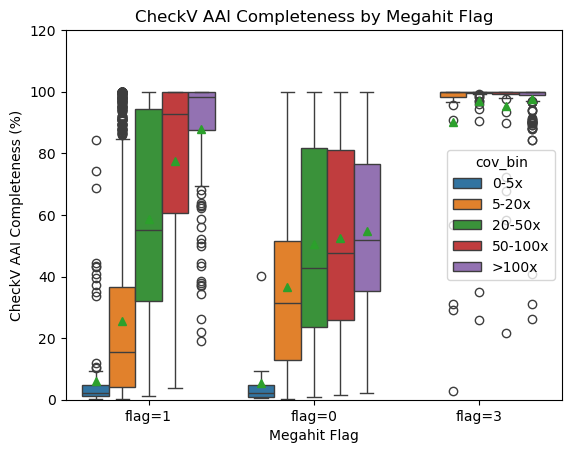

In [12]:
# check if megahit flag=1 with high cov is a signal of completeness
# !zgrep "^>" \
#     /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/enriched_virome_test/results/uhvdb/assemble/prjna524703/liang_*/liang_*enriched/megahit/liang_*enriched.contigs.fa.gz \
#     > megahit_contig_ids.txt


import polars as pl
import glob
import seaborn as sns
import matplotlib.pyplot as plt

megahit_ids = (
    pl.read_csv('megahit_contig_ids.txt', separator=' ', new_columns=['contig_id', 'flag', 'multi', 'len'])
        .with_columns([
            pl.col('contig_id').str.replace_all(r'^.*>', ''),
            pl.col('multi').str.replace_all('multi=', '').cast(pl.Float64),
            pl.col('len').str.replace_all('len=', '').cast(pl.Int64)
        ])
)

checkv_lst = []
for file in glob.glob('../../figure_4/activity_profiling/results/uhvdb/mine/prjna524703/*/*/checkv/*_completeness.tsv.gz'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'])
            .with_columns([pl.col('contig_id').str.split('|provirus').list[0]])
            [['contig_id', 'aai_completeness', 'aai_confidence']]
    )
    checkv_lst.append(df)

megahit_checkv_df = (
    pl.concat(checkv_lst)
        .join(megahit_ids, on='contig_id', how='inner')
        .with_columns([
            pl.when(pl.col('multi') >= 100).then(pl.lit('>100x'))
                .when(pl.col('multi') >= 50).then(pl.lit('50-100x'))
                .when(pl.col('multi') >= 20).then(pl.lit('20-50x'))
                .when(pl.col('multi') >= 5).then(pl.lit('5-20x'))
                .when(pl.col('multi') >= 0).then(pl.lit('0-5x'))
                .alias('cov_bin')
        ])
        # .filter(pl.col('aai_confidence').is_in(['high', 'medium']))
        # .filter(pl.col('len')>=10000)
)

# create a boxplot of completeness for each megahit flag
sns.boxplot(
    data=megahit_checkv_df,
    x='flag',
    y='aai_completeness',
    hue='cov_bin',
    hue_order=['0-5x', '5-20x', '20-50x', '50-100x', '>100x'],
    showmeans=True
)
plt.ylim(0, 120)
plt.xlabel('Megahit Flag')
plt.ylabel('CheckV AAI Completeness (%)')
plt.title('CheckV AAI Completeness by Megahit Flag')
plt.show()

In [ ]:
checkv_lst = []
for file in glob.glob('../../figure_4/activity_profiling/results/uhvdb/mine/prjna524703/*/*/checkv/*_quality_summary.tsv.gz'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'])
            .with_columns([pl.col('contig_id').str.split('|provirus').list[0]])
            [['contig_id', 'completeness_method', 'kmer_freq']]
    )
    checkv_lst.append(df)

megahit_checkv_df = (
    pl.concat(checkv_lst)
        .join(megahit_ids, on='contig_id', how='left')
        .with_columns([
            pl.when(pl.col('multi') >= 100).then(pl.lit('>100x'))
                .when(pl.col('multi') >= 50).then(pl.lit('50-100x'))
                .when(pl.col('multi') >= 20).then(pl.lit('20-50x'))
                .when(pl.col('multi') >= 5).then(pl.lit('5-20x'))
                .when(pl.col('multi') >= 0).then(pl.lit('0-5x'))
                .alias('cov_bin')
        ])
)

<Axes: xlabel='len', ylabel='Count'>

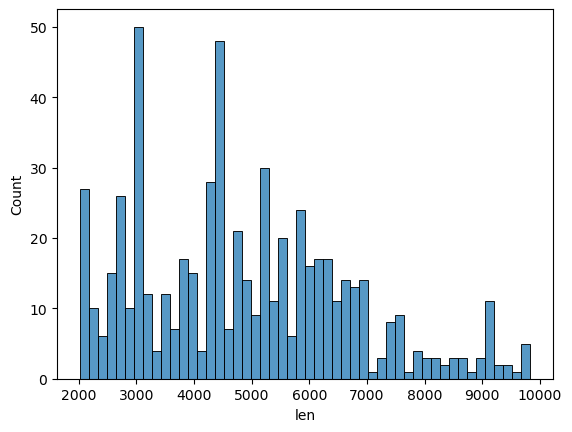

In [38]:
sns.histplot(megahit_ids.filter(pl.col('len') <= 10000).filter(pl.col('flag') == 'flag=3'), x='len', bins=50)

In [39]:
print("Number CheckV DTRs:", megahit_checkv_df.filter(pl.col('completeness_method').str.contains('DTR')).height)
print("Number megahit flag=3:", megahit_checkv_df.filter(pl.col('flag') == 'flag=3').height)
print("Number CheckV DTRs + megahit flag=3:", megahit_checkv_df.filter((pl.col('completeness_method').str.contains('DTR')) & (pl.col('flag') == 'flag=3')).height)
print("Number CheckV non-DTRs + megahit flag=3:", megahit_checkv_df.filter((~pl.col('completeness_method').str.contains('DTR')) & (pl.col('flag') == 'flag=3')).height)
print("Number CheckV DTRs + non-megahit flag=3:", megahit_checkv_df.filter((pl.col('completeness_method').str.contains('DTR')) & (pl.col('flag') != 'flag=3')).height)
print("Number CheckV ITRs:", megahit_checkv_df.filter(pl.col('completeness_method').str.contains('ITR')).height)

Number CheckV DTRs: 366
Number megahit flag=3: 350
Number CheckV DTRs + megahit flag=3: 336
Number CheckV non-DTRs + megahit flag=3: 12
Number CheckV DTRs + non-megahit flag=3: 30
Number CheckV ITRs: 4


In [30]:
megahit_checkv_df

contig_id,completeness_method,kmer_freq,flag,multi,len,cov_bin
str,str,f64,str,f64,i64,str
"""liang_3941_enriched_k251_211""","""DTR (high-confidence)""",1.04,"""flag=3""",59314.0,6171,""">100x"""
"""liang_3941_enriched_k251_1459""","""AAI-based (high-confidence)""",1.01,"""flag=1""",85.0,33857,"""50-100x"""
"""liang_3941_enriched_k251_1280""","""AAI-based (high-confidence)""",1.0,"""flag=1""",62.0,11072,"""50-100x"""
"""liang_3941_enriched_k251_440""","""AAI-based (high-confidence)""",1.0,"""flag=1""",126.0,34899,""">100x"""
"""liang_3941_enriched_k251_869""","""AAI-based (high-confidence)""",1.0,"""flag=1""",57.0,31062,"""50-100x"""
…,…,…,…,…,…,…
"""liang_3964_unenriched_k251_154…","""AAI-based (high-confidence)""",1.0,"""flag=0""",162.9705,241681,""">100x"""
"""liang_3964_unenriched_k251_956…","""AAI-based (high-confidence)""",1.0,"""flag=1""",18.0,58981,"""5-20x"""
"""liang_3964_unenriched_k251_195…","""AAI-based (high-confidence)""",1.0,"""flag=0""",117.9819,284962,""">100x"""


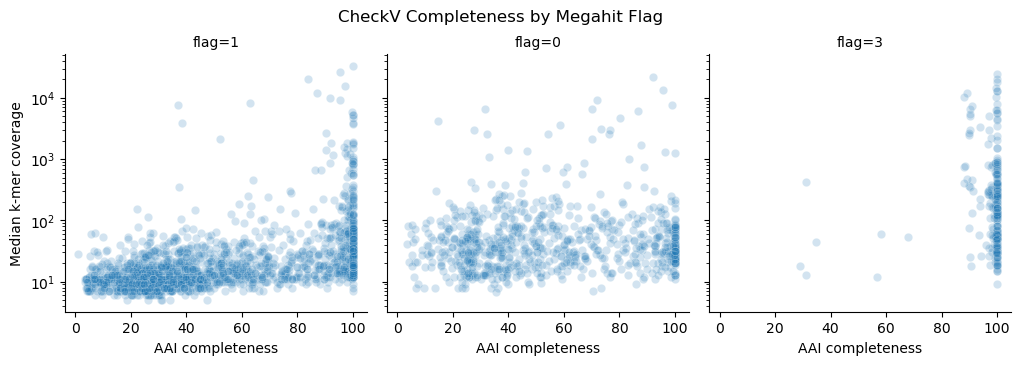

In [13]:
# facet scatterplot of completeness vs coverage by megahit flag
plot_df = megahit_checkv_df.select(['flag', 'aai_completeness', 'multi']).to_pandas()

g = sns.relplot(
    data=plot_df,
    x='aai_completeness',
    y='multi',
    col='flag',
    col_wrap=3,
    kind='scatter',
    alpha=0.2,
    height=3.5,
    aspect=1.0
)
g.set(yscale='log')
g.set_axis_labels('AAI completeness', 'Median k-mer coverage')
g.set_titles('{col_name}')
g.fig.suptitle('CheckV Completeness by Megahit Flag', y=1.03)
# set each x axis from 90 - 100
plt.show()

In [14]:
num_hicov = megahit_checkv_df.filter(pl.col('flag') == 'flag=1').filter(pl.col('multi') >= 100).height
num_complete = megahit_checkv_df.filter(pl.col('flag') == 'flag=1').filter(pl.col('multi') >= 100).filter(pl.col('aai_completeness') >= 90).height
print('Number of contigs with flag=1 and coverage >= 100x: {}'.format(num_hicov))
print('Number of contigs with flag=1, coverage >= 100x, and completeness >= 90%: {}'.format(num_complete))

Number of contigs with flag=1 and coverage >= 100x: 115
Number of contigs with flag=1, coverage >= 100x, and completeness >= 90%: 87


In [15]:
num_hicov = megahit_checkv_df.filter(pl.col('flag') == 'flag=0').filter(pl.col('multi') >= 100).height
num_complete = megahit_checkv_df.filter(pl.col('flag') == 'flag=0').filter(pl.col('multi') >= 100).filter(pl.col('aai_completeness') >= 90).height
print('Number of contigs with flag=0 and coverage >= 100x: {}'.format(num_hicov))
print('Number of contigs with flag=0, coverage >= 100x, and completeness >= 90%: {}'.format(num_complete))

Number of contigs with flag=0 and coverage >= 100x: 141
Number of contigs with flag=0, coverage >= 100x, and completeness >= 90%: 22


In [16]:
num_hicov = megahit_checkv_df.filter(pl.col('flag') == 'flag=3').filter(pl.col('multi') >= 100).height
num_complete = megahit_checkv_df.filter(pl.col('flag') == 'flag=3').filter(pl.col('multi') >= 100).filter(pl.col('aai_completeness') >= 90).height
print('Number of contigs with flag=0 and coverage >= 100x: {}'.format(num_hicov))
print('Number of contigs with flag=0, coverage >= 100x, and completeness >= 90%: {}'.format(num_complete))

Number of contigs with flag=0 and coverage >= 100x: 147
Number of contigs with flag=0, coverage >= 100x, and completeness >= 90%: 137


In [371]:
megahit_checkv_df.filter(pl.col('aai_completeness') >= 100).group_by('flag').len()

flag,len
str,u32
"""flag=1""",158
"""flag=3""",135
"""flag=0""",64


In [224]:
linear_complete = set(megahit_checkv_df.filter(pl.col('flag') =='flag=1').filter(pl.col('aai_completeness') >= 90).filter(pl.col('contig_id').str.contains('unenriched'))['contig_id'])

In [222]:
len(linear_complete)

108

In [223]:
enrich_v_unenrich.filter(pl.col('qname').is_in(linear_complete)).group_by('detection_status').len()

detection_status,len
str,u32
"""Both Detected""",22
"""Unenriched Only""",5


In [205]:
enrich_v_unenrich.filter(pl.col('detection_status') == 'Both Detected').height

902

In [206]:
enrich_v_unenrich.filter(pl.col('activity_score') >= 3).height

96